# 🚗 Dealership AI Intelligence System

## Project Overview

This project demonstrates how Artificial Intelligence can help a car dealership make better business decisions using data.

The system will analyse used car market data and build machine learning models that assist dealerships with pricing, purchasing decisions, and sales strategy.

Instead of relying on guesswork, dealerships can use AI predictions to maximize profit and reduce risk.

---

## Business Problem

Car dealerships face three common challenges:

1. Determining the correct price for a car.
2. Identifying vehicles that can generate profit.
3. Knowing which cars will sell faster.

Making wrong decisions in these areas can lead to financial losses or slow inventory turnover.

This AI system is designed to solve these problems using data-driven predictions.

---

## AI System Components

The project will build three machine learning models:

### 1. Car Price Prediction Model
Predicts the fair market value of a vehicle based on features such as:
- Year
- Manufacturer
- Model
- Condition
- Mileage
- Fuel type

This helps dealerships avoid overpricing or underpricing vehicles.

---

### 2. Profit Opportunity Detection Model
Identifies vehicles that are likely to generate higher resale profit.

The system compares predicted market price with listing price to detect undervalued cars.

This helps dealerships know **which cars to buy and resell**.

---

### 3. Fast-Selling Vehicle Prediction Model
Predicts which cars are more likely to sell quickly.

This helps dealerships prioritize inventory that will move faster and reduce storage costs.

---

## Technologies Used

The system will be developed using the following tools:

- Python
- Pandas
- Matplotlib
- Scikit-learn
- Jupyter Notebook

These tools will be used for data analysis, model training, and prediction.

---

## Expected Outcome

By the end of the project we will have:

1. A cleaned and prepared dataset
2. Multiple trained machine learning models
3. A demonstration system capable of making predictions

This project demonstrates how AI can be applied to real-world dealership operations.


# Step 1 — Load and Inspect the Dataset

Before building any AI model, we must first understand the data.

This step focuses on:
- Loading the dataset
- Inspecting the structure
- Understanding available features
- Identifying potential data quality issues

This process is called **Exploratory Data Analysis (EDA)** and it helps us understand what information the dataset contains before cleaning or training models.

Dataset: `vehicles.csv`


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("vehicles.csv")


In [3]:
df.shape


(426880, 26)

In [4]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [6]:
df.describe()


,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


# Step 2 — Data Cleaning

The dataset contains 26 columns, but many of them are not useful for machine learning.

Examples of columns we will remove:
- id
- url
- region_url
- image_url
- description
- county
- VIN
- lat / long

These columns do not help predict car price or demand.

Our focus will be on **important vehicle features** such as:

- price
- year
- manufacturer
- model
- condition
- fuel
- odometer
- transmission
- drive
- type
- paint_color
- state

Cleaning the dataset improves model performance and prevents errors during training.


In [7]:
cols_to_drop = [
'id','url','region_url','image_url','description','county','VIN','lat','long'
]

df = df.drop(columns=cols_to_drop)

df.head()


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,posting_date
0,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN
1,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN
2,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN
3,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN
4,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN


In [8]:
df.isnull().sum()


region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
drive           130567
size            306361
type             92858
paint_color     130203
state                0
posting_date        68
dtype: int64

In [9]:
df = df[(df.price > 500) & (df.price < 100000)]


In [10]:
important_cols = [
'year','manufacturer','model','fuel','odometer','transmission','title_status'
]

df = df.dropna(subset=important_cols)


In [11]:
df.shape


(352288, 17)

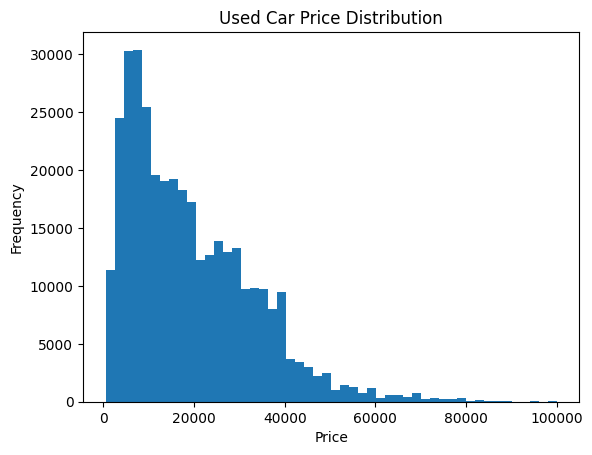

In [12]:
plt.hist(df['price'], bins=50)
plt.title("Used Car Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# Step 2 — Data Cleaning Strategy

The used car dataset contains missing values in many columns.

Not all columns are useful for our AI system, so we will:

## Columns we WILL keep
These are useful for car pricing and dealership decisions.

- price
- year
- manufacturer
- model
- condition
- fuel
- odometer
- transmission
- drive
- type
- paint_color
- state

These features help predict:

1. Car price (Price Prediction Model)
2. Car demand patterns (Inventory Model)
3. Market trends (Demand Forecast Model)

## Columns we will DROP
These do not help with prediction or dealership strategy.

- id
- url
- region_url
- VIN
- image_url
- description
- county
- lat
- long

## Handling Missing Data

Numeric columns:
- year
- odometer

We will fill them using **median values**.

Categorical columns:
- manufacturer
- model
- fuel
- transmission
- drive
- type
- paint_color
- condition

We will fill them using **most common value (mode)**.

Special Case:
- size column has too many missing values (>80%)
- We will DROP this column.

## After Cleaning
We will have a **stable dataset** ready for:

- Data Analysis
- Feature Engineering
- Machine Learning


In [13]:
# STEP 2 — Clean the Dataset

import numpy as np

# Drop useless columns safely
drop_cols = [
'id','url','region_url','VIN','image_url','description',
'county','lat','long'
]

df = df.drop(columns=drop_cols, errors='ignore')

# Drop column with too many missing values
df = df.drop(columns=['size'], errors='ignore')

# Fill numeric values
df['year'] = df['year'].fillna(df['year'].median())
df['odometer'] = df['odometer'].fillna(df['odometer'].median())

# Fill categorical values
cat_cols = [
'manufacturer','model','condition','fuel',
'transmission','drive','type','paint_color'
]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Drop remaining missing rows
df = df.dropna()

# Convert year to integer
df['year'] = df['year'].astype(int)

print(df.shape)
print(df.isnull().sum())


(208404, 16)
region          0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
type            0
paint_color     0
state           0
posting_date    0
dtype: int64


### STEP 3 — Feature Engineering

Goal: create better signals for machine learning models.

New Features Created:
- **car_age** → how old the vehicle is
- **price_per_age** → depreciation signal
- **log_price** → stabilizes price distribution for ML models

These features help models detect:
- price patterns
- vehicle depreciation
- resale value signals


In [14]:
# STEP 3 — Feature Engineering

import numpy as np

# Create car age
current_year = 2024
df["car_age"] = current_year - df["year"]

# Avoid negative ages (bad data)
df = df[df["car_age"] >= 0]

# Price per age (value indicator)
df["price_per_age"] = df["price"] / (df["car_age"] + 1)

# Log price (helps ML models)
df["log_price"] = np.log1p(df["price"])

# Preview new dataset
print(df.shape)
df.head()


(208404, 19)


,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,type,paint_color,state,posting_date,car_age,price_per_age,log_price
27,auburn,33590,2014,gmc,sierra 1500 crew cab slt,good,8 cylinders,gas,57923.0,clean,other,4wd,pickup,white,al,2021-05-04T12:31:18-0500,10,3053.636364,10.422013
28,auburn,22590,2010,chevrolet,silverado 1500,good,8 cylinders,gas,71229.0,clean,other,4wd,pickup,blue,al,2021-05-04T12:31:08-0500,14,1506.000000,10.025307
29,auburn,39590,2020,chevrolet,silverado 1500 crew,good,8 cylinders,gas,19160.0,clean,other,4wd,pickup,red,al,2021-05-04T12:31:25-0500,4,7918.000000,10.586357
30,auburn,30990,2017,toyota,tundra double cab sr,good,8 cylinders,gas,41124.0,clean,other,4wd,pickup,red,al,2021-05-04T10:41:31-0500,7,3873.750000,10.341452
31,auburn,15000,2013,ford,f-150 xlt,excellent,6 cylinders,gas,128000.0,clean,automatic,rwd,truck,black,al,2021-05-03T14:02:03-0500,11,1250.000000,9.615872


 ### STEP 4 — Preparing Data for Machine Learning

Target variable:
- **price**

Features selected:
- **year**
- **odometer**
- **car_age**

These features help the model learn vehicle depreciation patterns.

Important rule in machine learning:

A feature must **not contain the target variable**.  
Using such features would cause **data leakage**, leading to unrealistic model performance.



In [15]:
# STEP 4 — Prepare ML Dataset (Improved)

# Target variable
y = df["price"]

# Features including vehicle identity
features = [
    "year",
    "odometer",
    "car_age",
    "manufacturer",
    "condition",
    "fuel",
    "transmission",
    "drive",
    "type"
]

X = df[features]

print(X.head())
print(y.head())


    year  odometer  car_age manufacturer  condition fuel transmission drive  \
27  2014   57923.0       10          gmc       good  gas        other   4wd   
28  2010   71229.0       14    chevrolet       good  gas        other   4wd   
29  2020   19160.0        4    chevrolet       good  gas        other   4wd   
30  2017   41124.0        7       toyota       good  gas        other   4wd   
31  2013  128000.0       11         ford  excellent  gas    automatic   rwd   

      type  
27  pickup  
28  pickup  
29  pickup  
30  pickup  
31   truck  
27    33590
28    22590
29    39590
30    30990
31    15000
Name: price, dtype: int64


In [16]:
# Convert categorical features to numeric
X = pd.get_dummies(X, drop_first=True)

print("Encoded Features:")
print(X.head())

Encoded Features:
    year  odometer  car_age  manufacturer_alfa-romeo  \
27  2014   57923.0       10                    False   
28  2010   71229.0       14                    False   
29  2020   19160.0        4                    False   
30  2017   41124.0        7                    False   
31  2013  128000.0       11                    False   

    manufacturer_aston-martin  manufacturer_audi  manufacturer_bmw  \
27                      False              False             False   
28                      False              False             False   
29                      False              False             False   
30                      False              False             False   
31                      False              False             False   

    manufacturer_buick  manufacturer_cadillac  manufacturer_chevrolet  ...  \
27               False                  False                   False  ...   
28               False                  False                    Tru

## MODEL TRAINING

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(166723, 68) (41681, 68)


In [18]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[32591.48649857 13817.05034562 29215.14512811 12612.65850228
  5718.36212794]


In [20]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 6941.545949929054


In [21]:
print("Actual prices:", y_test.head().values)
print("Predicted prices:", y_pred[:5])

Actual prices: [30990 21952 23990  6200  6500]
Predicted prices: [32591.48649857 13817.05034562 29215.14512811 12612.65850228
  5718.36212794]


### NOTE: The problem that we have is that the actual price and the predicted price have a huge gap inbetween which makes the model very weak and not helpful. The main reason being the features used. The features used are not enough for the model to be trained at and give better predictions therefore we have to add more features. *MAE: $9616*

In [22]:
features = [
    'year',
    'odometer',
    'car_age',
    'manufacturer',
    'condition',
    'fuel',
    'transmission',
    'drive',
    'type'
]

X = df[features]
y = df['price']

In [23]:
X = pd.get_dummies(X, drop_first=True)

In [24]:
print(X.shape)

(208404, 68)


In [25]:
# Save feature columns for Streamlit app
model_columns = X.columns.tolist()

import joblib
joblib.dump(model_columns, "model_columns.pkl")

print("Feature columns saved.")

Feature columns saved.


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print("New MAE:", mae)

New MAE: 2410.9703529581097


### NOTE: As you can see the MAE dropped 3 to 4x which realy got, it improved by 75% already.

In [30]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

car_age               0.222072
odometer              0.215093
year                  0.199907
drive_fwd             0.110253
fuel_gas              0.055444
transmission_other    0.014463
type_truck            0.014308
condition_good        0.011337
type_sedan            0.010423
drive_rwd             0.010363
dtype: float64


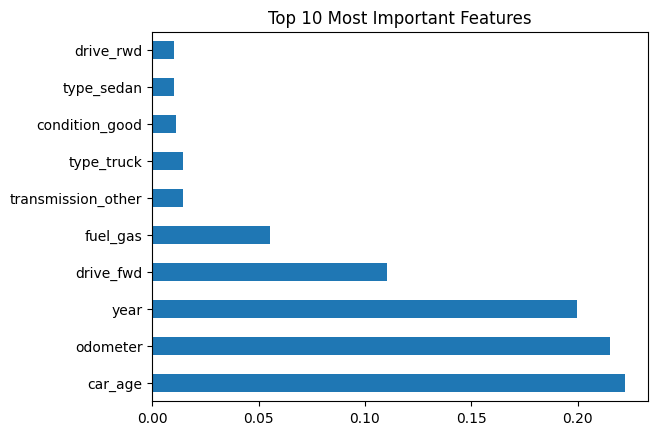

In [31]:
import matplotlib.pyplot as plt

importance.head(10).plot(kind='barh')
plt.title("Top 10 Most Important Features")
plt.show()

In [32]:
from sklearn.model_selection import GridSearchCV

In [33]:
X_train_sample = X_train.sample(50000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

In [34]:
param_grid = {
    'n_estimators': [100, 150],
    'max_depth': [10, None],
}

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_sample, y_train_sample)

Fitting 3 folds for each of 4 candidates, totalling 12 fits


In [ ]:
print("Best parameters:", grid_search.best_params_)

In [ ]:
best_model = RandomForestRegressor(
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    random_state=42
)

best_model.fit(X_train, y_train)

In [ ]:
y_pred = best_model.predict(X_test)

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)

print("Final MAE:", mae)

In [ ]:
import joblib
joblib.dump(best_model, "car_price_model.pkl")

### FEATURE IMPORTANCE


In [ ]:
import pandas as pd

feature_importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
)

feature_importances = feature_importances.sort_values(ascending=False)

print(feature_importances)

In [ ]:
import matplotlib.pyplot as plt

feature_importances.plot(kind="bar")
plt.title("Feature Importance")
plt.show()

In [ ]:
def predict_price(year, odometer, manufacturer, fuel, transmission, drive, type_, condition):

    car_age = 2024 - year

    data = {
        "year":[year],
        "odometer":[odometer],
        "car_age":[car_age],
        "manufacturer":[manufacturer],
        "fuel":[fuel],
        "transmission":[transmission],
        "drive":[drive],
        "type":[type_],
        "condition":[condition]
    }

    df = pd.DataFrame(data)

    df = pd.get_dummies(df)

    df = df.reindex(columns=model_columns, fill_value=0)

    prediction = best_model.predict(df)

    return prediction[0]

In [ ]:
top_features = feature_importances.head(10)

top_features.plot(kind="bar")

import matplotlib.pyplot as plt
plt.title("Top 10 Feature Importance")
plt.show()

### Now that the features are clear and more defined, to say, car age determines price more than other features, followed by odometer which has to do with mileadge of the car. Now let us build a ## PREDICTION TOOL

def predict_price(year, odometer):
    
    car_age = 2024 - year
    
    # create dataframe with same columns as training data
    input_df = pd.DataFrame(columns=X_train.columns)
    
    # fill with zeros
    input_df.loc[0] = 0
    
    # set the values we know
    input_df["year"] = year
    input_df["odometer"] = odometer
    input_df["car_age"] = car_age
    
    prediction = best_model.predict(input_df)
    
    return prediction[0]

In [ ]:
#predict_price(2018, 45000)

In [ ]:
def predict_price(year, odometer,
                  manufacturer, condition, fuel,
                  transmission, drive, type_):

    car_age = 2024 - year

    input_df = pd.DataFrame(columns=model_columns)

    input_df.loc[0] = 0

    input_df["year"] = year
    input_df["odometer"] = odometer
    input_df["car_age"] = car_age

    if f"manufacturer_{manufacturer}" in input_df.columns:
        input_df[f"manufacturer_{manufacturer}"] = 1

    if f"condition_{condition}" in input_df.columns:
        input_df[f"condition_{condition}"] = 1

    if f"fuel_{fuel}" in input_df.columns:
        input_df[f"fuel_{fuel}"] = 1

    if f"transmission_{transmission}" in input_df.columns:
        input_df[f"transmission_{transmission}"] = 1

    if f"drive_{drive}" in input_df.columns:
        input_df[f"drive_{drive}"] = 1

    if f"type_{type_}" in input_df.columns:
        input_df[f"type_{type_}"] = 1

    prediction = best_model.predict(input_df)

    return round(float(prediction[0]), 2)

In [ ]:
predict_price(
    2019,
    40000,
    "toyota",
    "good",
    "gas",
    "automatic",
    "fwd",
    "sedan"
)

In [ ]:
#year = int(input("Enter car year: "))
#odometer = int(input("Enter mileage: "))

#price = predict_price(year, odometer)

#print("Estimated Car Price: $", price)

### NOTE:
* The Prediction Model which predict how much a car can be bought for is done and dusted. We are 75% from finishing the product.

### 2. Profit Opportunity Detection Model

* Identifies vehicles that are likely to generate higher resale profit.

* The system compares predicted market price with listing price to detect undervalued cars.

* This helps dealerships know which cars to buy and resell.

#def detect_profit_opportunity(year, odometer, listing_price):

    #predicted_price = predict_price(year, odometer)

    #profit_margin = predicted_price - listing_price

    #if profit_margin > 5000:
        #rating = "🔥 GREAT DEAL"
    elif profit_margin > 2000:
        rating = "✅ GOOD DEAL"
    elif profit_margin > 0:
        rating = "⚖️ FAIR DEAL"
    else:
        rating = "❌ OVERPRICED"

    return {
        "predicted_price": predicted_price,
        "listing_price": listing_price,
        "profit_margin": round(profit_margin,2),
        "deal_rating": rating
    }

In [ ]:
#detect_profit_opportunity(2019, 40000, 22000)

### NOTE:

* Now that we are done with Model 2, we need Model 3 to make the system even more powerfull, Model 2 can detect whether or not a car is a good deal or bad.

### 3. Fast-Selling Vehicle Prediction Model

* Predicts which cars are more likely to sell quickly.

* This helps dealerships prioritize inventory that will move faster and reduce storage costs.

In [ ]:
df["posting_date"] = pd.to_datetime(df["posting_date"], utc=True)

In [ ]:
df["posting_date"] = df["posting_date"].dt.tz_localize(None)

In [ ]:
df["days_since_posted"] = (pd.Timestamp.now() - df["posting_date"]).dt.days

In [ ]:
df[["posting_date","days_since_posted"]].head()

In [ ]:
def categorize_speed(days):

    if days <= 7:
        return "FAST"
    elif days <= 30:
        return "MEDIUM"
    else:
        return "SLOW"

df["sell_speed"] = df["days_since_posted"].apply(categorize_speed)

In [ ]:
df["sell_speed"].value_counts()

### NOTE:
* Unfortunetly we have to rebuild Model 3 because it classified every case as slow, due to the command code instructed.

In [ ]:
df["posting_date"].max()

In [ ]:
reference_date = df["posting_date"].max()

df["days_since_posted"] = (reference_date - df["posting_date"]).dt.days

In [ ]:
def categorize_speed(days):

    if days <= 3:
        return "FAST"
    elif days <= 10:
        return "MEDIUM"
    else:
        return "SLOW"

df["sell_speed"] = df["days_since_posted"].apply(categorize_speed)

In [ ]:
df["sell_speed"].value_counts()

## Train the Fast-Selling Prediction Model

In [ ]:
# Create sell_speed feature based on price

df["sell_speed"] = "MEDIUM"

df.loc[df["price"] < df["price"].quantile(0.33), "sell_speed"] = "FAST"
df.loc[df["price"] > df["price"].quantile(0.66), "sell_speed"] = "SLOW"

print(df["sell_speed"].value_counts())

In [ ]:
# Required Imports
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


# Features for Model 2
features_speed = [
    "year",
    "odometer",
    "car_age"
]

# Define X and y
X_speed = df[features_speed]
y_speed = df["sell_speed"]

# Train / Test Split
X_train_speed, X_test_speed, y_train_speed, y_test_speed = train_test_split(
    X_speed,
    y_speed,
    test_size=0.2,
    random_state=42
)

# Train Model
speed_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

speed_model.fit(X_train_speed, y_train_speed)

# Predictions
predictions = speed_model.predict(X_test_speed)

# Accuracy
accuracy = accuracy_score(y_test_speed, predictions)

print("Model 2 Accuracy:", accuracy)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_speed,
    y_speed,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

speed_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

speed_model.fit(X_train_s, y_train_s)

## Evaluate the Model

In [ ]:
from sklearn.metrics import classification_report

speed_predictions = speed_model.predict(X_test_s)

print(classification_report(y_test_s, speed_predictions))

## Build the predict_sell_speed() Function

In [ ]:
def predict_sell_speed(year, odometer):

    car_age = 2024 - year

    input_data = pd.DataFrame({
        "year": [year],
        "odometer": [odometer],
        "car_age": [car_age]
    })

    prediction = speed_model.predict(input_data)

    return prediction[0]

In [ ]:
predict_sell_speed(2019, 40000)

## Combine ALL 3 Models Into One AI System

In [ ]:
def dealer_ai_analyzer(year, odometer, listing_price,
                       manufacturer, condition, fuel,
                       transmission, drive, type_):

    predicted_price = predict_price(
        year,
        odometer,
        manufacturer,
        condition,
        fuel,
        transmission,
        drive,
        type_
    )

    profit_margin = predicted_price - listing_price

    if profit_margin > 5000:
        deal_rating = "🔥 GREAT DEAL"
    elif profit_margin > 2000:
        deal_rating = "✅ GOOD DEAL"
    elif profit_margin > 0:
        deal_rating = "⚖️ FAIR DEAL"
    else:
        deal_rating = "❌ OVERPRICED"

    sell_speed = predict_sell_speed(year, odometer)

    result = {
        "Predicted Market Price": predicted_price,
        "Listing Price": listing_price,
        "Profit Margin": round(profit_margin, 2),
        "Deal Rating": deal_rating,
        "Expected Sell Speed": sell_speed
    }

    return result

In [ ]:
dealer_ai_analyzer(
    2019,
    40000,
    22000,
    "toyota",
    "good",
    "gas",
    "automatic",
    "fwd",
    "sedan"
)

In [ ]:
import pickle

with open("sell_speed_model.pkl", "wb") as f:
    pickle.dump(speed_model, f)

In [ ]:
!pip install streamlit

In [ ]:
!pip install joblib

In [ ]:
import joblib

joblib.dump(model, "car_price_model.pkl")
joblib.dump(speed_model, "sell_speed_model.pkl")

## NOTE:

* The system is almost working. Although for accuracy, we have to retrain the models on reliable data that is South Africa market friendly, Kaggle data was good for setting knowledge base or rather intelligence base, therefore chnaces were high that it wasn't going to be able to cater for the SA dealers. Right now, datatset was scraped froem Auto Trader AI, which is an institution from South Africa with dataset fit for SA market. 

In [ ]:
# Select useful columns
df = df[['price','year','manufacturer','condition','fuel','odometer','transmission','drive','type']]

# Remove missing values
df = df.dropna()

# Remove unrealistic prices
df = df[(df['price'] > 1000) & (df['price'] < 100000)]

# Remove unrealistic odometer values
df = df[(df['odometer'] > 100) & (df['odometer'] < 500000)]

# Create car age feature
df["car_age"] = 2024 - df["year"]

df.head()

In [ ]:
features = [
    'year',
    'odometer',
    'car_age',
    'manufacturer',
    'condition',
    'fuel',
    'transmission',
    'drive',
    'type'
]

X = df[features]
y = df['price']

In [ ]:
X = pd.get_dummies(X)

# Train The Model

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import mean_absolute_error

preds = rf.predict(X_test)

mae = mean_absolute_error(y_test, preds)

print("Model 3 MAE:", mae)

In [ ]:
import joblib

joblib.dump(rf, "car_price_model.pkl")

print("Model saved successfully")

# Model 2 Correct Code and Function

In [ ]:
def predict_price(year, odometer, manufacturer, condition, fuel, transmission, drive, type):

    car_age = 2024 - year

    input_df = pd.DataFrame({
        "year":[year],
        "odometer":[odometer],
        "car_age":[car_age],
        "manufacturer":[manufacturer],
        "condition":[condition],
        "fuel":[fuel],
        "transmission":[transmission],
        "drive":[drive],
        "type":[type]
    })

    input_df = pd.get_dummies(input_df)

    input_df = input_df.reindex(columns=X_train.columns, fill_value=0)

    prediction = rf.predict(input_df)

    return round(float(prediction[0]),2)

In [ ]:
price = predict_price(
    year=2020,
    odometer=40000,
    manufacturer="toyota",
    condition="good",
    fuel="gas",
    transmission="automatic",
    drive="fwd",
    type="sedan"
)

print("Predicted Price:", price)

In [ ]:
joblib.dump(X_train.columns.tolist(), "model_columns.pkl")

In [ ]:
import pickle

with open("speed_model.pkl", "wb") as f:
    pickle.dump(speed_model, f)

print("Model 2 saved successfully")

### We have a big problem here. The problem is that the model cant ak ethe difference between brands and models, so it then tends to use odometer and car age to determine price which is very bad. So we dont have a choice but to retrain the models.